<a href="https://colab.research.google.com/github/PHYNiX29/Cognitive-Computing/blob/main/Vaibhav_Sundriyal_102316077_Assignment9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1.  Write a unique paragraph (5-6 sentences) about your favorite topic (e.g., sports,
technology, food, books, etc.).
1. Convert text to lowercase and remove punctuation.
2. Tokenize the text into words and sentences.
3. Remove stopwords (using NLTK's stopwords list).
4. Display word frequency distribution (excluding stopwords).

In [3]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

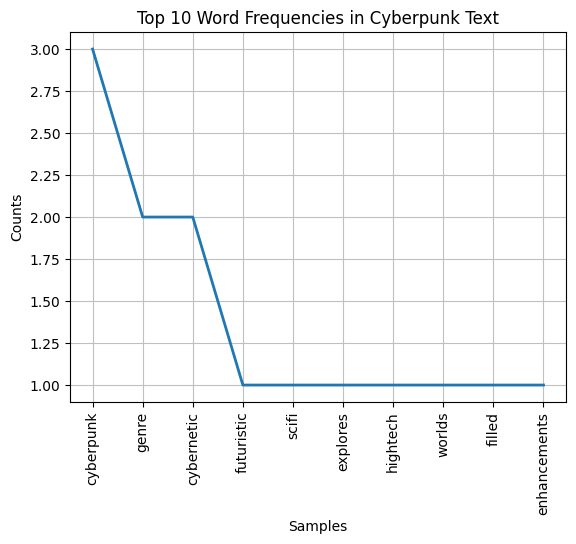

In [4]:
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.probability import FreqDist
import matplotlib.pyplot as plt

text = '''Cyberpunk is a futuristic sci-fi genre that explores high-tech worlds filled with cybernetic enhancements, mega-corporations, and gritty urban landscapes.
It often portrays dystopian societies where advanced AI, hacking, and augmented reality are everyday realities.
Influential works like Blade Runner, Neuromancer, and the video game Cyberpunk 2077 define the aesthetic and themes of rebellion, identity, and surveillance.
Cyberpunk fuses elements of noir fiction, Japanese culture, and electronic music to craft immersive, neon-lit environments.
The genre questions the cost of technological progress and human augmentation in a corporatized future.
Underground hackers, rogue androids, and cybernetic mercenaries drive stories that blur the line between man and machine.'''

text = text.lower().translate(str.maketrans('', '', string.punctuation))

words = word_tokenize(text)
sentences = sent_tokenize(text)

stopword_list = set(stopwords.words('english'))
meaningful_words = [token for token in words if token not in stopword_list]

frequency_distribution = FreqDist(meaningful_words)

frequency_distribution.plot(10, title="Top 10 Word Frequencies in Cyberpunk Text")
plt.show()

Q2: Stemming and Lemmatization
1. Take the tokenized words from Ques on 1 (after stopword removal).
2. Apply stemming using NLTK's PorterStemmer and LancasterStemmer.
3. Apply lemmatization on using NLTK's WordNetLemmatizer.
4. Compare and display results of both techniques.

In [5]:
from nltk.stem import PorterStemmer, LancasterStemmer, WordNetLemmatizer

porter_stemmer = PorterStemmer()
lancaster_stemmer = LancasterStemmer()
lemmatizer = WordNetLemmatizer()

porter_results = [porter_stemmer.stem(word) for word in meaningful_words]
lancaster_results = [lancaster_stemmer.stem(word) for word in meaningful_words]
lemmatized_words = [lemmatizer.lemmatize(word) for word in meaningful_words]

for word, porter, lancaster, lemma in zip(meaningful_words, porter_results, lancaster_results, lemmatized_words):
    print(f"{word:15} | Porter: {porter:15} | Lancaster: {lancaster:15} | Lemma: {lemma}")


cyberpunk       | Porter: cyberpunk       | Lancaster: cyberpunk       | Lemma: cyberpunk
futuristic      | Porter: futurist        | Lancaster: fut             | Lemma: futuristic
scifi           | Porter: scifi           | Lancaster: scif            | Lemma: scifi
genre           | Porter: genr            | Lancaster: genr            | Lemma: genre
explores        | Porter: explor          | Lancaster: expl            | Lemma: explores
hightech        | Porter: hightech        | Lancaster: hightech        | Lemma: hightech
worlds          | Porter: world           | Lancaster: world           | Lemma: world
filled          | Porter: fill            | Lancaster: fil             | Lemma: filled
cybernetic      | Porter: cybernet        | Lancaster: cybernet        | Lemma: cybernetic
enhancements    | Porter: enhanc          | Lancaster: enh             | Lemma: enhancement
megacorporations | Porter: megacorpor      | Lancaster: megacorp        | Lemma: megacorporations
gritty         

Q3. Regular Expressions and Text Splitting
1. Take their original text from Ques on 1.
2. Use regular expressions to:
a. Extract all words with more than 5 letters.
b. Extract all numbers (if any exist in their text).
c. Extract all capitalized words.
3. Use text splitting techniques to:
a. Split the text into words containing only alphabets (removing digits and special characters).
b. Extract words starting with a vowel.

In [6]:
import re

long_words = re.findall(r'\b\w{6,}\b', text)
numeric_values = re.findall(r'\b\d+\b', text)
capitalized_terms = re.findall(r'\b[A-Z][a-z]*\b', text)
alphabetic_only = re.findall(r'\b[a-zA-Z]+\b', text)
vowel_starting = [word for word in alphabetic_only if re.match(r'^[AEIOUaeiou]', word)]

print("Words longer than 5 letters:", long_words)
print("Numeric values:", numeric_values)
print("Capitalized terms:", capitalized_terms)
print("Alphabetic words:", alphabetic_only)
print("Words starting with a vowel:", vowel_starting)


Words longer than 5 letters: ['cyberpunk', 'futuristic', 'explores', 'hightech', 'worlds', 'filled', 'cybernetic', 'enhancements', 'megacorporations', 'gritty', 'landscapes', 'portrays', 'dystopian', 'societies', 'advanced', 'hacking', 'augmented', 'reality', 'everyday', 'realities', 'influential', 'runner', 'neuromancer', 'cyberpunk', 'define', 'aesthetic', 'themes', 'rebellion', 'identity', 'surveillance', 'cyberpunk', 'elements', 'fiction', 'japanese', 'culture', 'electronic', 'immersive', 'neonlit', 'environments', 'questions', 'technological', 'progress', 'augmentation', 'corporatized', 'future', 'underground', 'hackers', 'androids', 'cybernetic', 'mercenaries', 'stories', 'between', 'machine']
Numeric values: ['2077']
Capitalized terms: []
Alphabetic words: ['cyberpunk', 'is', 'a', 'futuristic', 'scifi', 'genre', 'that', 'explores', 'hightech', 'worlds', 'filled', 'with', 'cybernetic', 'enhancements', 'megacorporations', 'and', 'gritty', 'urban', 'landscapes', 'it', 'often', 'por

Q4. Custom Tokenization on & Regex-based Text Cleaning
1. Take original text from Ques on 1.
2. Write a custom tokenization on func on that:
a. Removes punctuation and special symbols, but keeps contractions (e.g., "isn't" should not be split into "is" and "n't").
b. Handles hyphenated words as a single token (e.g., "state-of-the-art" remains a single token).
c. Tokenizes numbers separately but keeps decimal numbers intact (e.g., "3.14" should remain as is).

3. Use Regex Substitutions (re.sub) to:
a. Replace email addresses with '<EMAIL>' placeholder.
b. Replace URLs with '<URL>' placeholder.
c. Replace phone numbers (formats: 123-456-7890 or +91 9876543210) with '<PHONE>' placeholder.

In [8]:
def tokenize_custom(input_text):
    token_pattern = r"\b\w+(?:-\w+)*'\w+|\b\w+(?:-\w+)*|\d+\.\d+|\d+"
    return re.findall(token_pattern, input_text)

def replace_emails(input_text):
    return re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w{2,4}\b', '<EMAIL>', input_text)

def replace_urls(input_text):
    return re.sub(r'https?://\S+|www\.\S+', '<URL>', input_text)

def replace_phone_numbers(input_text):
    return re.sub(r'(\+?\d{1,3}[ -]?)?\(?\d{3}\)?[ -]?\d{3}[ -]?\d{4}', '<PHONE>', input_text)

sanitized_text = replace_emails(text)
sanitized_text = replace_urls(sanitized_text)
sanitized_text = replace_phone_numbers(sanitized_text)

custom_tokens = tokenize_custom(sanitized_text)

print("Custom Tokens:", custom_tokens)


Custom Tokens: ['cyberpunk', 'is', 'a', 'futuristic', 'scifi', 'genre', 'that', 'explores', 'hightech', 'worlds', 'filled', 'with', 'cybernetic', 'enhancements', 'megacorporations', 'and', 'gritty', 'urban', 'landscapes', 'it', 'often', 'portrays', 'dystopian', 'societies', 'where', 'advanced', 'ai', 'hacking', 'and', 'augmented', 'reality', 'are', 'everyday', 'realities', 'influential', 'works', 'like', 'blade', 'runner', 'neuromancer', 'and', 'the', 'video', 'game', 'cyberpunk', '2077', 'define', 'the', 'aesthetic', 'and', 'themes', 'of', 'rebellion', 'identity', 'and', 'surveillance', 'cyberpunk', 'fuses', 'elements', 'of', 'noir', 'fiction', 'japanese', 'culture', 'and', 'electronic', 'music', 'to', 'craft', 'immersive', 'neonlit', 'environments', 'the', 'genre', 'questions', 'the', 'cost', 'of', 'technological', 'progress', 'and', 'human', 'augmentation', 'in', 'a', 'corporatized', 'future', 'underground', 'hackers', 'rogue', 'androids', 'and', 'cybernetic', 'mercenaries', 'drive'